In [1]:
##### Test colinearity of predictors (for capital, labor, and raster models) to each other and to target variables

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data

capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/identify_colinear_predictors"

### Correlation matrix of predictors

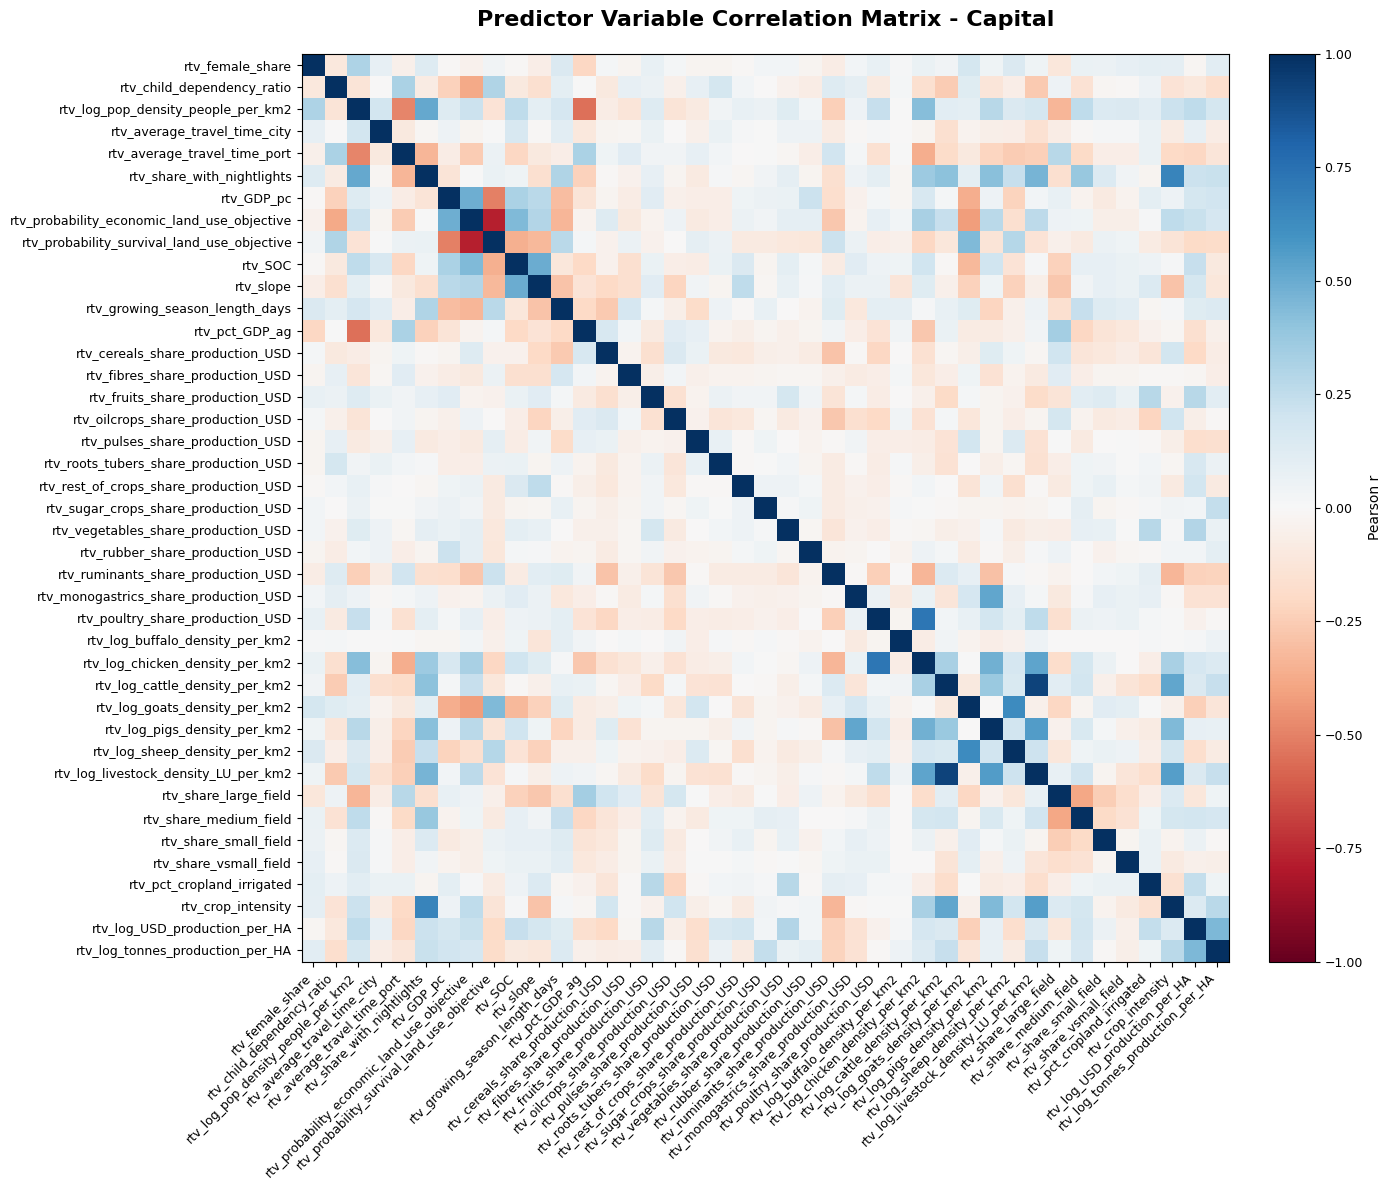

In [4]:
### CAPITAL MODEL

# drop target variables


predictor_cols = ['rtv_female_share', 'rtv_child_dependency_ratio', 
       'rtv_log_pop_density_people_per_km2', 'rtv_average_travel_time_city', 'rtv_average_travel_time_port',
       'rtv_share_with_nightlights', 'rtv_GDP_pc',
       'rtv_probability_economic_land_use_objective', 'rtv_probability_survival_land_use_objective',
       'rtv_SOC', 'rtv_slope', 'rtv_growing_season_length_days',
       'rtv_pct_GDP_ag',
       'rtv_cereals_share_production_USD', 'rtv_fibres_share_production_USD',
       'rtv_fruits_share_production_USD', 'rtv_oilcrops_share_production_USD',
       'rtv_pulses_share_production_USD', 'rtv_roots_tubers_share_production_USD',
       'rtv_rest_of_crops_share_production_USD',
       'rtv_sugar_crops_share_production_USD', 'rtv_vegetables_share_production_USD',
       'rtv_rubber_share_production_USD', 'rtv_ruminants_share_production_USD',
       'rtv_monogastrics_share_production_USD', 'rtv_poultry_share_production_USD',
       'rtv_log_buffalo_density_per_km2',
       'rtv_log_chicken_density_per_km2', 'rtv_log_cattle_density_per_km2',
       'rtv_log_goats_density_per_km2', 'rtv_log_pigs_density_per_km2',
       'rtv_log_sheep_density_per_km2', 'rtv_log_livestock_density_LU_per_km2',
       'rtv_share_large_field', 'rtv_share_medium_field', 'rtv_share_small_field', 'rtv_share_vsmall_field',  
       'rtv_pct_cropland_irrigated', 'rtv_crop_intensity',
       'rtv_log_USD_production_per_HA', 'rtv_log_tonnes_production_per_HA',
]

corr_capital = capital_model[predictor_cols].corr()

n_vars = len(predictor_cols)
fig, ax = plt.subplots(figsize=(14, 12))

cax = ax.imshow(corr_capital.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(predictor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(predictor_cols, fontsize=9)

ax.set_title("Predictor Variable Correlation Matrix - Capital", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/predictor_corr_matrix_capital.png", dpi=300, bbox_inches='tight')

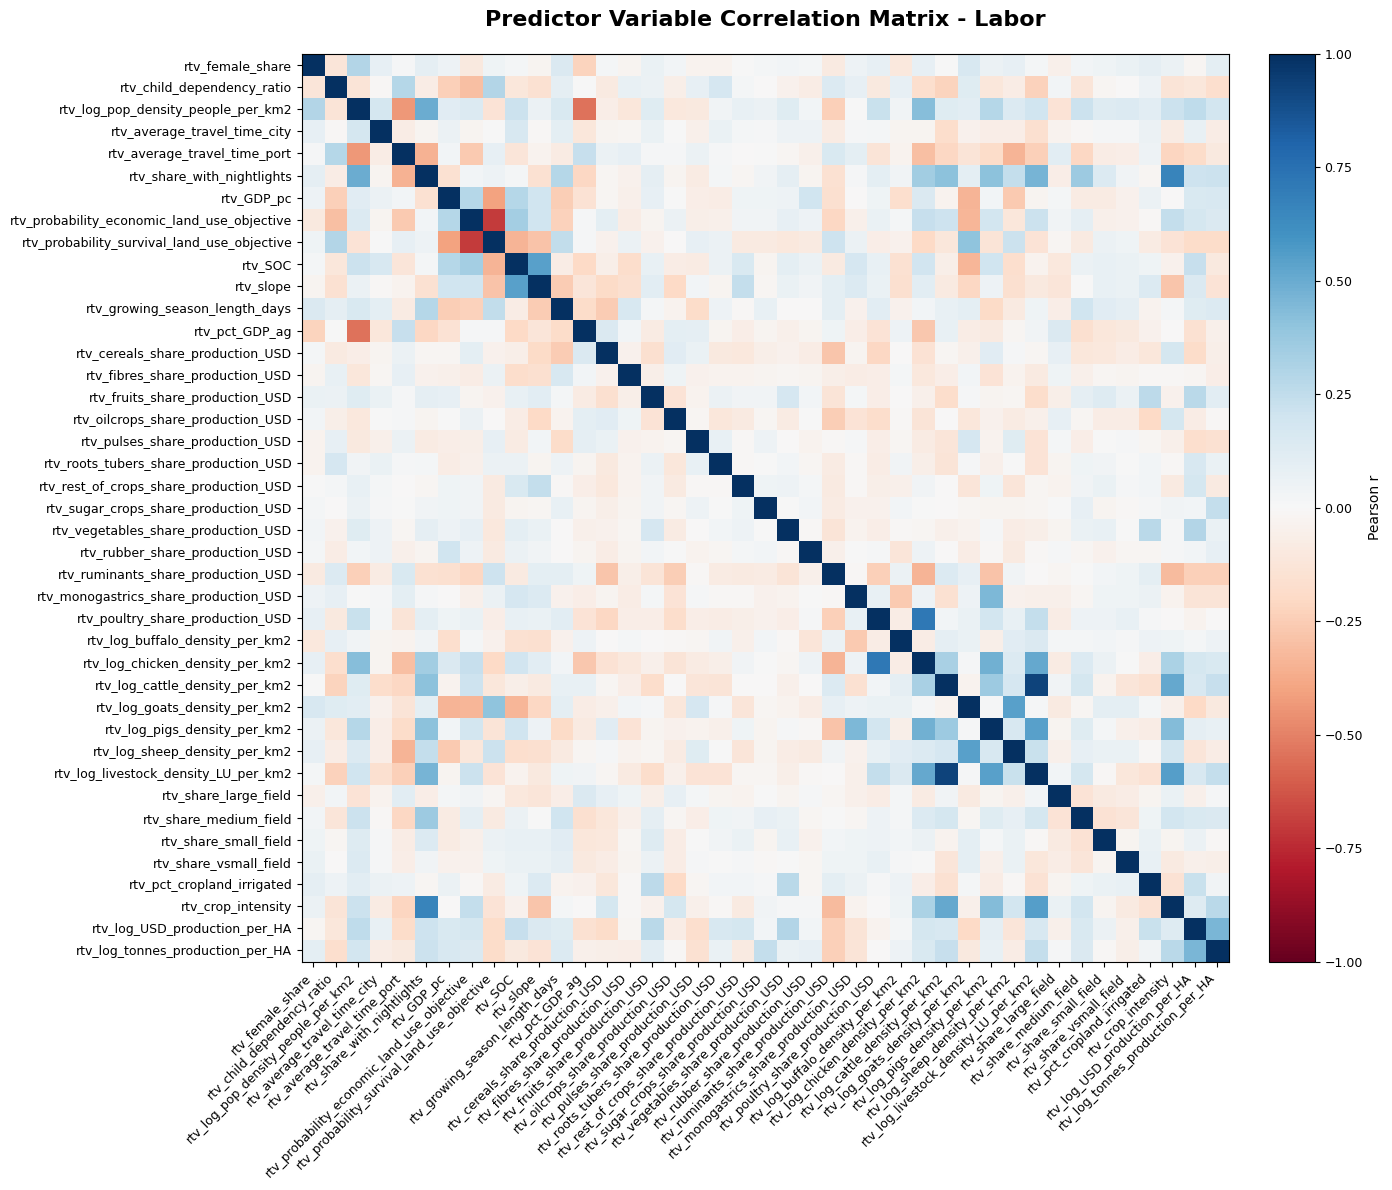

In [5]:
### LABOR MODEL

# drop target variables

corr_labor = labor_model[predictor_cols].corr()

n_vars = len(predictor_cols)
fig, ax = plt.subplots(figsize=(14, 12))

cax = ax.imshow(corr_labor.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(predictor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(predictor_cols, fontsize=9)

ax.set_title("Predictor Variable Correlation Matrix - Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/predictor_corr_matrix_labor.png", dpi=300, bbox_inches='tight')

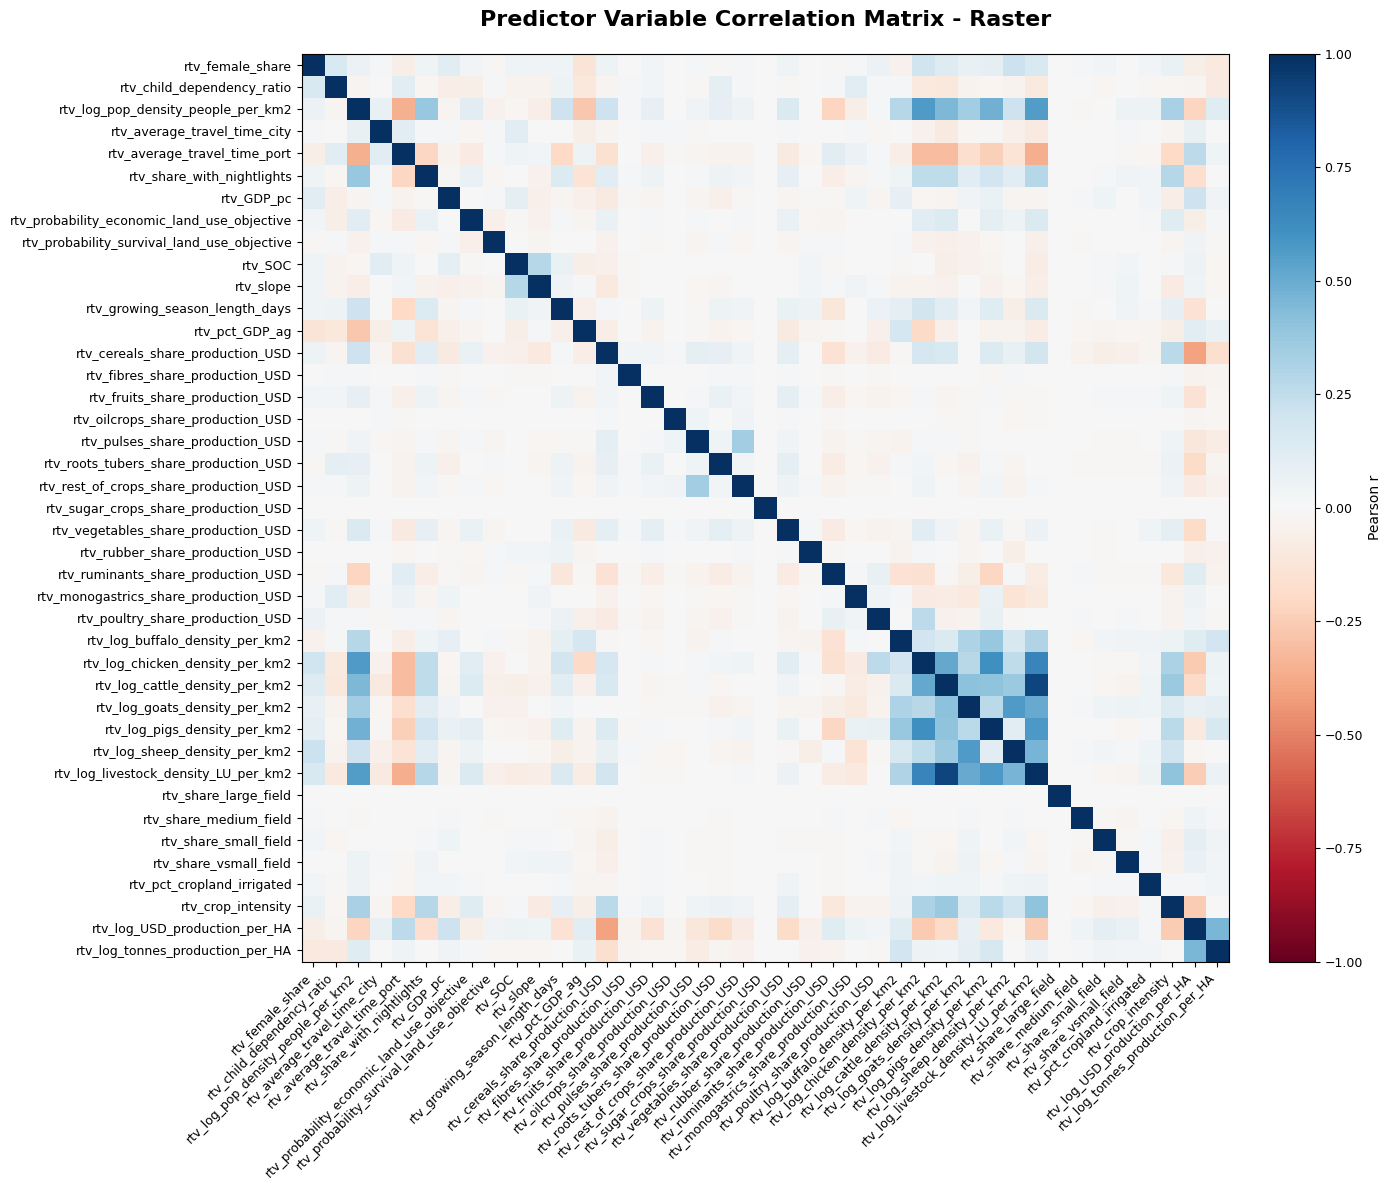

In [6]:
### RASTER MODEL

corr_raster = raster_model[predictor_cols].corr()

n_vars = len(predictor_cols)
fig, ax = plt.subplots(figsize=(14, 12))

cax = ax.imshow(corr_raster.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(predictor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(predictor_cols, fontsize=9)

ax.set_title("Predictor Variable Correlation Matrix - Raster", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/predictor_corr_matrix_raster.png", dpi=300, bbox_inches='tight')

### Correlation matrix of predictors and target variables

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_41055/3828341748.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


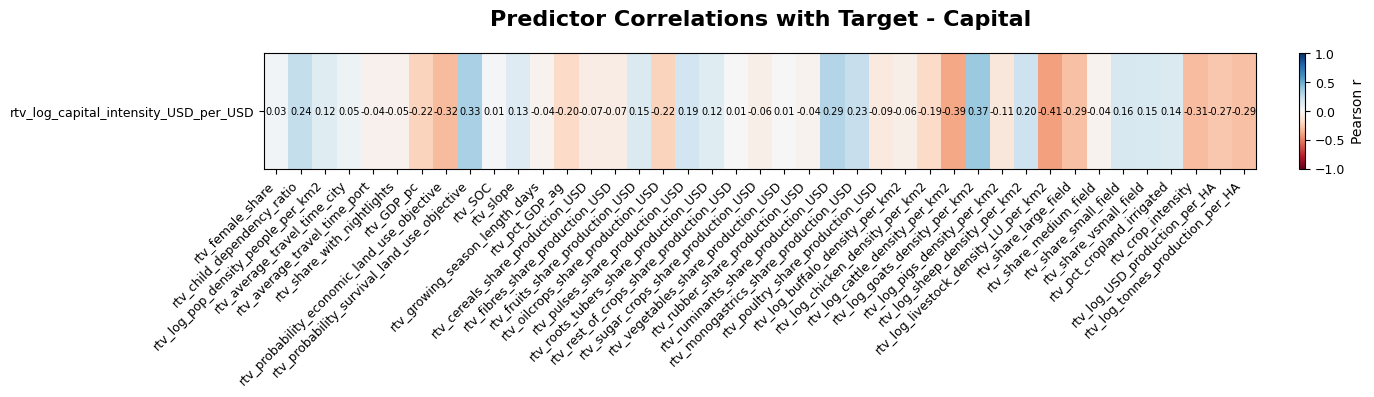

In [8]:
### CAPITAL MODEL - Target Correlations

target_col = 'rtv_log_capital_intensity_USD_per_USD'  

# Correlations of each predictor against the target (1 x n_vars)
corr_target = capital_model[predictor_cols + [target_col]].corr()[[target_col]].loc[predictor_cols]

n_vars = len(predictor_cols)
fig, ax = plt.subplots(figsize=(14, 1.5))

cax = ax.imshow(corr_target.values.T, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(range(n_vars))
ax.set_xticklabels(predictor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks([0])
ax.set_yticklabels([target_col], fontsize=9)

# Annotate each cell with its Pearson r value
for j, val in enumerate(corr_target.values.flatten()):
    text_color = 'black' if abs(val) < 0.5 else 'black'
    ax.text(j, 0, f'{val:.2f}', ha='center', va='center',
            fontsize=7, color=text_color, zorder=5, clip_on=False)

ax.set_title("Predictor Correlations with Target - Capital", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/target_corr_matrix_capital.png", dpi=300, bbox_inches='tight')

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_41055/3981258450.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


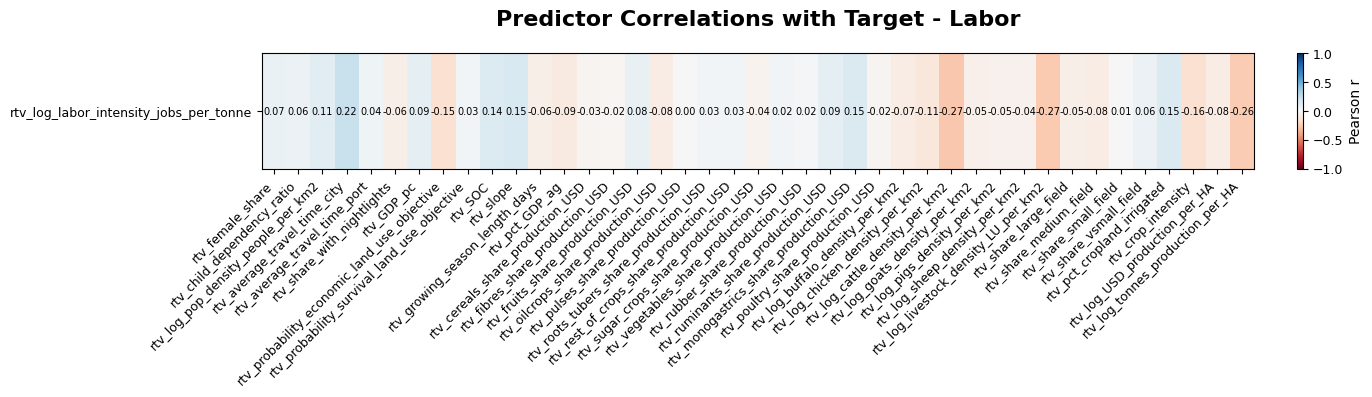

In [11]:
### CAPITAL MODEL - Target Correlations

target_col = 'rtv_log_labor_intensity_jobs_per_tonne'  

# Correlations of each predictor against the target (1 x n_vars)
corr_target = labor_model[predictor_cols + [target_col]].corr()[[target_col]].loc[predictor_cols]

n_vars = len(predictor_cols)
fig, ax = plt.subplots(figsize=(14, 1.5))

cax = ax.imshow(corr_target.values.T, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xticks(range(n_vars))
ax.set_xticklabels(predictor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks([0])
ax.set_yticklabels([target_col], fontsize=9)

# Annotate each cell with its Pearson r value
for j, val in enumerate(corr_target.values.flatten()):
    text_color = 'black' if abs(val) < 0.5 else 'black'
    ax.text(j, 0, f'{val:.2f}', ha='center', va='center',
            fontsize=7, color=text_color, zorder=5, clip_on=False)

ax.set_title("Predictor Correlations with Target - Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/target_corr_matrix_labor.png", dpi=300, bbox_inches='tight')